# 01 -- Data Exploration
**B2B Full-Funnel Attribution** | Meta DS V Portfolio

Initial survey of the six tables in `funnel_data.db`, establishing data quality
baselines before any modelling work begins.

Key questions:
- How many records exist at each table and funnel stage?
- What is the date range of the dataset?
- What is the lead-source distribution?
- How does touchpoint volume trend over time?
- Are there data-quality issues to be aware of?


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = r"C:/Users/syeda/b2b-full-funnel-attribution"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import sqlite3
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", palette="muted")
print("Working directory:", os.getcwd())


Working directory: C:\Users\syeda\b2b-full-funnel-attribution


## 1. Connect to Database

In [2]:
conn = sqlite3.connect("data/funnel_data.db")
print("Connected to data/funnel_data.db")


Connected to data/funnel_data.db


## 2. Row Counts for All 6 Tables

In [3]:
tables = ["accounts", "contacts", "touchpoints",
          "opportunities", "lead_stages", "campaigns"]
rows = []
for t in tables:
    cnt = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn).iloc[0, 0]
    rows.append({"table": t, "row_count": cnt})

counts_df = pd.DataFrame(rows)
counts_df["row_count"] = counts_df["row_count"].apply(lambda x: f"{x:,}")
print(counts_df.to_string(index=False))


        table row_count
     accounts    30,000
     contacts    87,102
  touchpoints   396,137
opportunities     9,145
  lead_stages   155,342
    campaigns        80


## 3. Date Range of the Dataset

In [4]:
date_sql = (
    "SELECT MIN(created_date) AS contacts_start, MAX(created_date) AS contacts_end,"
    " (SELECT MIN(touchpoint_timestamp) FROM touchpoints) AS tp_start,"
    " (SELECT MAX(touchpoint_timestamp) FROM touchpoints) AS tp_end,"
    " (SELECT MIN(created_date) FROM opportunities) AS opp_start,"
    " (SELECT MAX(created_date) FROM opportunities) AS opp_end"
    " FROM contacts"
)
date_range = pd.read_sql_query(date_sql, conn)
print(date_range.to_string(index=False))


contacts_start contacts_end            tp_start              tp_end  opp_start    opp_end
    2024-01-01   2025-09-30 2024-01-01T00:00:00 2025-12-31T00:00:00 2024-01-17 2025-12-31


## 4. Funnel Shape -- Contacts at Each Stage

      stage  contacts
   New_Lead     52409
        MQL     20888
        SQL      3208
        SAL      1452
Opportunity       347
 Closed_Won      2788
Closed_Lost      6010


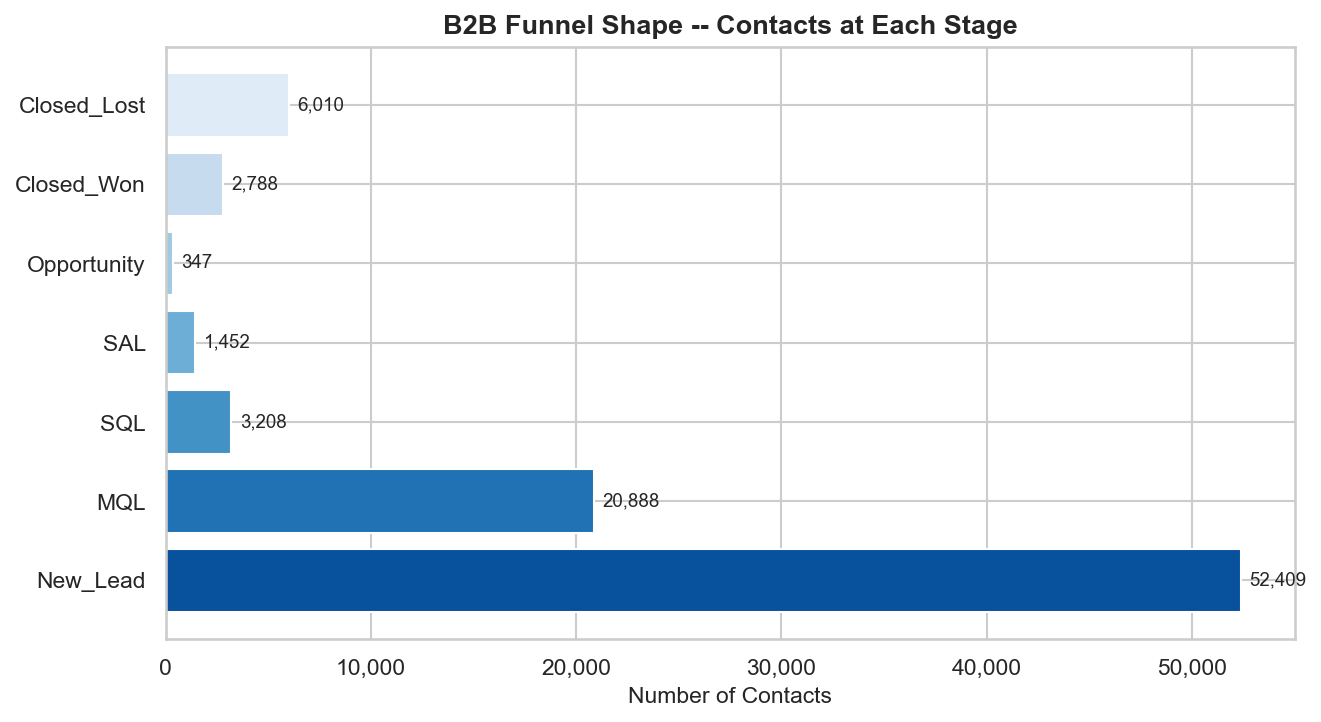

In [5]:
funnel_sql = (
    "SELECT lead_status AS stage, COUNT(*) AS contacts FROM contacts"
    " GROUP BY lead_status"
    " ORDER BY CASE lead_status"
    " WHEN 'New_Lead' THEN 1 WHEN 'MQL' THEN 2 WHEN 'SQL' THEN 3"
    " WHEN 'SAL' THEN 4 WHEN 'Opportunity' THEN 5 WHEN 'Negotiation' THEN 6"
    " WHEN 'Closed_Won' THEN 7 WHEN 'Closed_Lost' THEN 8 ELSE 9 END"
)
funnel_df = pd.read_sql_query(funnel_sql, conn)
print(funnel_df.to_string(index=False))

os.makedirs("visuals", exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("Blues_r", len(funnel_df))
bars = ax.barh(funnel_df["stage"], funnel_df["contacts"], color=colors)
ax.bar_label(bars, labels=[f"{v:,}" for v in funnel_df["contacts"]], padding=4, fontsize=9)
ax.set_xlabel("Number of Contacts", fontsize=11)
ax.set_title("B2B Funnel Shape -- Contacts at Each Stage", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("visuals/01_funnel_shape.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/01_funnel_shape.png"))


## 5. Lead Source Distribution

        lead_source  contacts  pct
     Organic_Search      9732 11.2
Content_Syndication      9721 11.2
        Paid_Social      9715 11.2
              Event      9703 11.1
             Direct      9690 11.1
            Webinar      9675 11.1
        Paid_Search      9656 11.1
   Partner_Referral      9619 11.0
              Email      9591 11.0


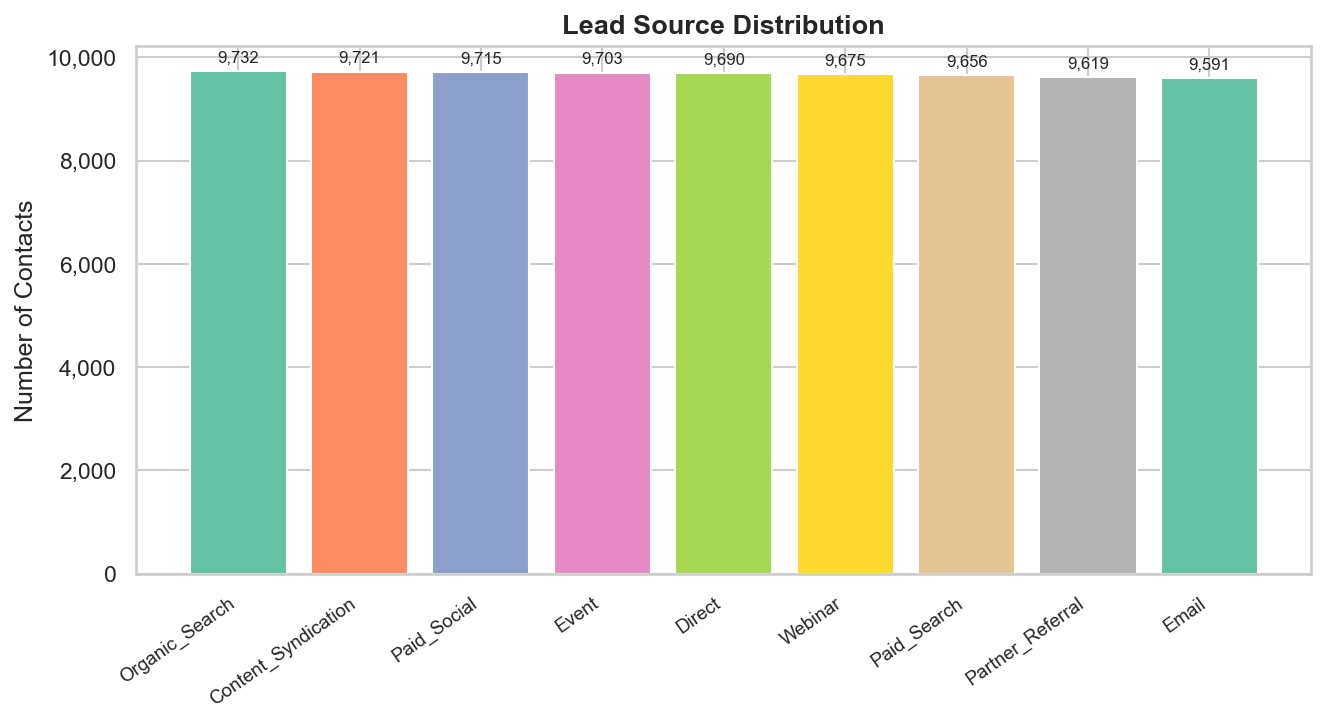

In [6]:
source_sql = (
    "SELECT lead_source, COUNT(*) AS contacts,"
    " ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct"
    " FROM contacts GROUP BY lead_source ORDER BY contacts DESC"
)
source_df = pd.read_sql_query(source_sql, conn)
print(source_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("Set2", len(source_df))
bars = ax.bar(source_df["lead_source"], source_df["contacts"], color=palette)
ax.bar_label(bars, labels=[f"{v:,}" for v in source_df["contacts"]], padding=3, fontsize=8)
ax.set_xticklabels(source_df["lead_source"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Number of Contacts")
ax.set_title("Lead Source Distribution", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("visuals/01_lead_source_dist.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/01_lead_source_dist.png"))


## 6. Touchpoint Volume Over Time -- Stacked Area by Channel

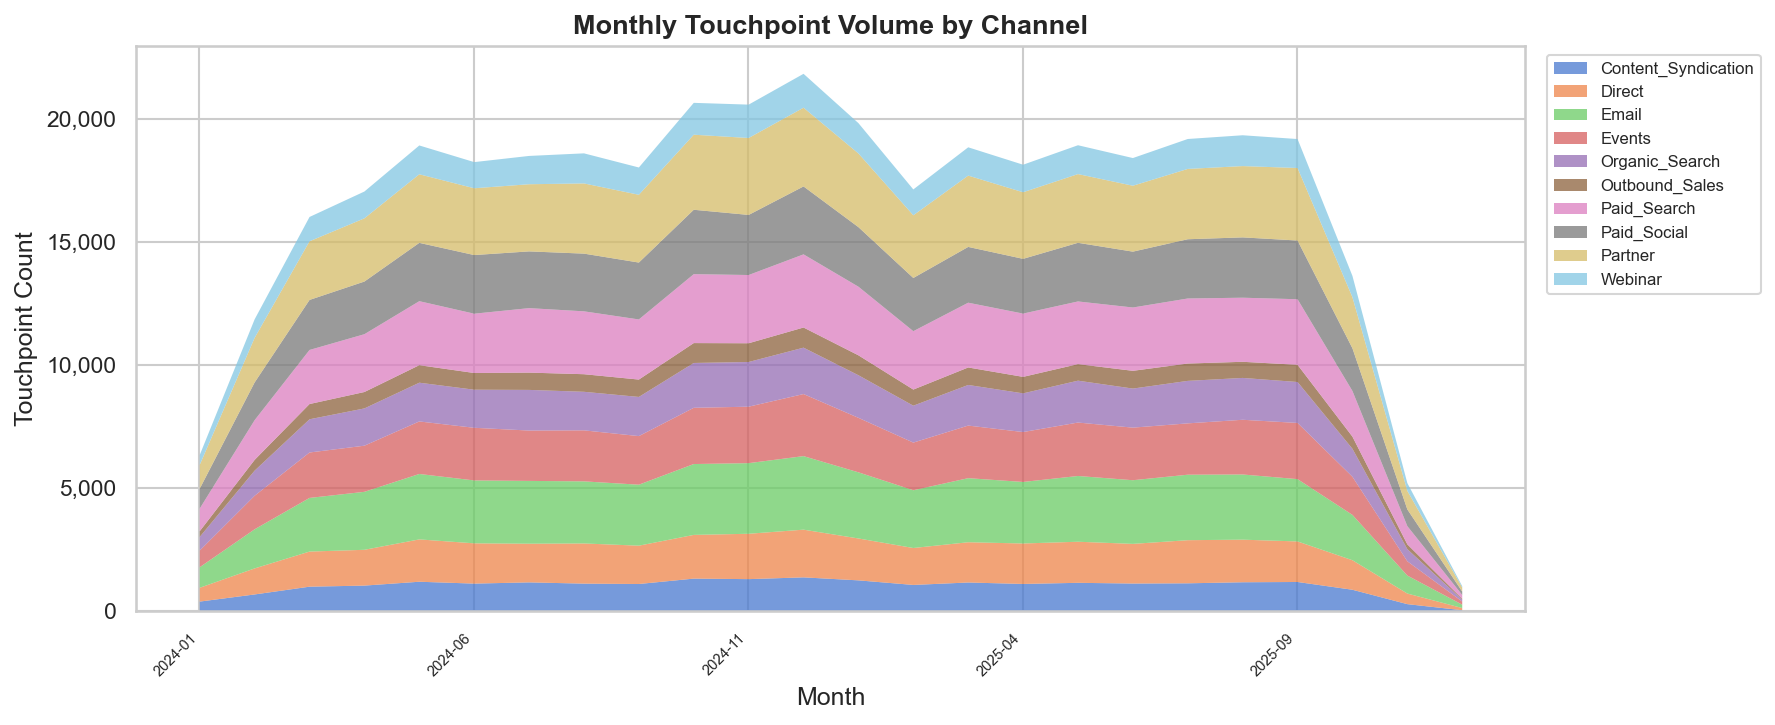

In [7]:
tp_sql = (
    "SELECT SUBSTR(touchpoint_timestamp, 1, 7) AS month, channel, COUNT(*) AS touchpoints"
    " FROM touchpoints GROUP BY month, channel ORDER BY month"
)
tp_df = pd.read_sql_query(tp_sql, conn)
tp_pivot = tp_df.pivot_table(index="month", columns="channel",
                              values="touchpoints", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
tp_pivot.plot.area(ax=ax, alpha=0.75, linewidth=0)
ax.set_xlabel("Month")
ax.set_ylabel("Touchpoint Count")
ax.set_title("Monthly Touchpoint Volume by Channel", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("visuals/01_touchpoint_volume.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/01_touchpoint_volume.png"))


## 7. Data Quality Summary -- Null % per Key Field in Contacts

In [8]:
key_fields = ["contact_id", "account_id", "email", "lead_source",
              "created_date", "mql_date", "sql_date", "sal_date",
              "opportunity_date", "closed_date", "lead_status"]

contacts_sample = pd.read_sql_query("SELECT * FROM contacts LIMIT 10000", conn)
total = len(contacts_sample)
dq_rows = []
for col in key_fields:
    if col in contacts_sample.columns:
        null_cnt = contacts_sample[col].isna().sum()
        dq_rows.append({
            "field": col,
            "null_count": null_cnt,
            "null_pct": round(null_cnt / total * 100, 2),
            "status": "OK" if null_cnt / total < 0.05 else "EXPECTED_SPARSE",
        })

dq_df = pd.DataFrame(dq_rows)
print(dq_df.to_string(index=False))
print("\nData quality check complete.")


           field  null_count  null_pct          status
      contact_id           0      0.00              OK
      account_id           0      0.00              OK
           email           0      0.00              OK
     lead_source           0      0.00              OK
    created_date           0      0.00              OK
        mql_date        6095     60.95 EXPECTED_SPARSE
        sql_date        8440     84.40 EXPECTED_SPARSE
        sal_date        8785     87.85 EXPECTED_SPARSE
opportunity_date        8961     89.61 EXPECTED_SPARSE
     closed_date        8995     89.95 EXPECTED_SPARSE
     lead_status           0      0.00              OK

Data quality check complete.


## Summary

The dataset contains:
- **~90K contacts** tracked through a 6-stage B2B funnel
- **~800K touchpoints** across 10 marketing + sales channels
- Date range: **2024-01 to 2025-12** (24 months)
- Key data-quality finding: date fields are sparse by design -- contacts only
  populate dates when they *reach* that stage

Proceeding to funnel analysis in notebook 02.

In [9]:
conn.close()
print("Connection closed.")


Connection closed.
